# DeepLense Task VII: Physics-Informed Neural Networks (PINNs)
### Substructure Classification in Strong Gravitational Lensing
**Author:** Vansh Jain  
**Abstract:** This notebook implements a Physics-Informed Neural Network (PINN) designed to classify dark matter substructures (no-sub, subhalo, and vortex). By integrating the gravitational lensing equation $\beta = \theta - \alpha$ directly into the architecture, we enforce physical consistency and flux conservation, moving beyond purely statistical pixel-level classification.

In [1]:
import os
import random
import logging
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from dataclasses import dataclass, field
from torch.optim.lr_scheduler import ReduceLROnPlateau

# --- ACADEMIC LOGGING CONFIGURATION ---
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger("DeepLense_TaskVII")

# --- GLOBAL CONFIGURATION ---
@dataclass
class PINNConfig:
    # Environment Paths
    data_dir: Path = Path("/kaggle/input/datasets/vanshdistsys2/deeplense-specifictask-7-dataset/dataset")
    artifact_dir: Path = Path("/kaggle/working/artifacts")
    
    # Mathematical Constraints
    lambda_physics: float = 0.01  # Relaxed to prioritize classification convergence
    alpha_scaling_factor: float = 0.2
    
    # Optimization Hyperparameters
    learning_rate: float = 3e-4
    weight_decay: float = 1e-4
    batch_size: int = 32
    epochs: int = 150             # High ceiling for PINN convergence
    
    # Topological Constants
    input_channels: int = 1
    image_resolution: int = 150
    num_classes: int = 3
    class_mapping: dict[str, int] = field(default_factory=lambda: {"no": 0, "sphere": 1, "vort": 2})
    random_seed: int = 42

config = PINNConfig()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Execution environment initialized on {device}")

2026-03-21 15:46:59 | INFO | Execution environment initialized on cuda


In [2]:
def seed_environment(config: PINNConfig) -> None:
    """Forces deterministic operations across CPU and GPU hardware."""
    os.environ["PYTHONHASHSEED"] = str(config.random_seed)
    random.seed(config.random_seed)
    np.random.seed(config.random_seed)
    torch.manual_seed(config.random_seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(config.random_seed)
        torch.cuda.manual_seed_all(config.random_seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    
    logger.info(f"Environment locked to seed {config.random_seed}. Determinism enforced.")

seed_environment(config)

2026-03-21 15:46:59 | INFO | Environment locked to seed 42. Determinism enforced.


## Phase 1: Automated Dataset Profiling & Telemetry
Before optimization, we must verify the topological constraints of the dataset. This stage probes the raw `.npy` artifacts to ensure spatial dimensions (150x150) and radiometric bounds are consistent across the train/val partitions.

In [3]:
def probe_nested_dataset(dataset_path: str) -> None:
    """Extracts structural telemetry and radiometric bounds from the dataset."""
    root_dir = Path(dataset_path)
    train_dir = root_dir / "train"
    
    logger.info(f"Analyzing dataset topology at: {train_dir.resolve()}")

    if not train_dir.exists():
        logger.error(f"Partition directory not found at {train_dir}")
        return

    classes = [d for d in train_dir.iterdir() if d.is_dir()]
    logger.info(f"Identified {len(classes)} morphological classes.")
    
    sample_files = []
    for cls_dir in classes:
        files = [f for f in cls_dir.iterdir() if f.is_file()]
        logger.info(f"Class [{cls_dir.name}]: {len(files)} samples indexed.")
        if files:
            sample_files.append(files[0])

    if not sample_files:
        return
        
    try:
        sample_file = sample_files[0]
        arr = np.load(sample_file)
        logger.info("--- Tensor Telemetry ---")
        logger.info(f"Spatial Dimensions: {arr.shape} | Precision: {arr.dtype}")
        logger.info(f"Dynamic Range: [{arr.min():.2f}, {arr.max():.2f}] | Global Mean: {arr.mean():.4f}")
    except Exception as e:
        logger.error(f"Artifact ingestion failed: {str(e)}")

probe_nested_dataset(str(config.data_dir))

2026-03-21 15:46:59 | INFO | Analyzing dataset topology at: /kaggle/input/datasets/vanshdistsys2/deeplense-specifictask-7-dataset/dataset/train
2026-03-21 15:46:59 | INFO | Identified 3 morphological classes.
2026-03-21 15:47:28 | INFO | Class [no]: 10000 samples indexed.
2026-03-21 15:47:58 | INFO | Class [vort]: 10000 samples indexed.
2026-03-21 15:48:28 | INFO | Class [sphere]: 10000 samples indexed.
2026-03-21 15:48:28 | INFO | --- Tensor Telemetry ---
2026-03-21 15:48:28 | INFO | Spatial Dimensions: (1, 150, 150) | Precision: float64
2026-03-21 15:48:28 | INFO | Dynamic Range: [0.00, 1.00] | Global Mean: 0.0903


## Phase 2: Architectural Design
### 1. Multiscale Alpha Extractor
Estimates the 2D deflection field $\alpha$ using dilated convolutions to capture both local substructure perturbations and global lensing profiles.
### 2. Physics Inversion Layer
Uses `F.grid_sample` to perform a differentiable spatial warping, reconstructing the unlensed source galaxy $\beta$.
### 3. Residual Classifier
A deep ResNet-style head that processes the concatenated physical state $[\theta, \alpha, \beta]$ for high-fidelity classification.

In [4]:
class LensingDataset(Dataset):
    """Maps physical data paths to normalized PyTorch tensors."""
    def __init__(self, split_dir: Path, class_mapping: dict[str, int]):
        self.split_dir, self.class_mapping = split_dir, class_mapping
        self.file_paths, self.labels = [], []
        self._build_index()

    def _build_index(self):
        for class_name, label_idx in self.class_mapping.items():
            class_dir = self.split_dir / class_name
            if class_dir.exists():
                files = list(class_dir.glob("*.npy"))
                self.file_paths.extend(files)
                self.labels.extend([label_idx] * len(files))
        logger.info(f"Indexed {len(self.file_paths)} artifacts from {self.split_dir.name} partition.")

    def __len__(self) -> int: return len(self.file_paths)

    def __getitem__(self, idx: int):
        arr = np.load(self.file_paths[idx]).astype(np.float32)
        # Min-Max Normalization to prevent gradient explosion
        a_min, a_max = arr.min(), arr.max()
        if a_max > a_min: arr = (arr - a_min) / (a_max - a_min)
        return torch.from_numpy(arr), torch.tensor(self.labels[idx], dtype=torch.long)

class MultiscaleAlphaExtractor(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        self.init_conv = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.path1 = nn.Conv2d(32, 32, kernel_size=3, padding=1, dilation=1)
        self.path2 = nn.Conv2d(32, 32, kernel_size=3, padding=2, dilation=2)
        self.path3 = nn.Conv2d(32, 32, kernel_size=3, padding=4, dilation=4)
        self.reducer = nn.Conv2d(96, 32, kernel_size=1)
        self.final = nn.Conv2d(32, 2, kernel_size=3, padding=1)

    def forward(self, x):
        x = F.relu(self.init_conv(x))
        feat = torch.cat([self.path1(x), self.path2(x), self.path3(x)], dim=1)
        feat = F.relu(self.reducer(feat))
        return torch.tanh(self.final(feat))

class ResidualClassifier(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        def res_block(in_f, out_f):
            return nn.Sequential(
                nn.Conv2d(in_f, out_f, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm2d(out_f), nn.ReLU(inplace=True),
                nn.Conv2d(out_f, out_f, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_f), nn.ReLU(inplace=True)
            )
        self.layers = nn.Sequential(res_block(4, 32), res_block(32, 64), res_block(64, 128), res_block(128, 256))
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.layers(x)
        return self.fc(F.adaptive_avg_pool2d(x, (1, 1)).flatten(1))

class LensingPINN(nn.Module):
    def __init__(self, config: PINNConfig):
        super().__init__()
        self.scaling = config.alpha_scaling_factor
        self.alpha_net = MultiscaleAlphaExtractor(config.input_channels)
        self.classifier = ResidualClassifier(config.num_classes)

    def forward(self, theta):
        B, _, H, W = theta.shape
        alpha = self.alpha_net(theta) * self.scaling
        y, x = torch.meshgrid(torch.linspace(-1, 1, H), torch.linspace(-1, 1, W), indexing='ij')
        grid = torch.stack([x, y], dim=-1).to(theta.device).unsqueeze(0).repeat(B, 1, 1, 1) - alpha.permute(0, 2, 3, 1)
        beta = F.grid_sample(theta, grid, align_corners=True, padding_mode='zeros')
        return self.classifier(torch.cat([theta, alpha, beta], dim=1)), alpha, beta

## Phase 3: Multi-Objective Optimization
The network is optimized using a composite loss function:
$$L = L_{CE} + \lambda (L_{flux} + L_{sparsity} + L_{TV})$$
This ensures the model not only identifies the correct class but also obeys General Relativity by conserving total flux and maintaining a smooth deflection field.

In [5]:
class PhysicsInformedLoss(nn.Module):
    def __init__(self, lambda_physics: float):
        super().__init__()
        self.lambda_phys = lambda_physics
        self.ce = nn.CrossEntropyLoss()

    def _physics_constraints(self, theta, alpha, beta):
        flux_error = torch.abs(theta.sum(dim=(2,3)) - beta.sum(dim=(2,3))).mean()
        sparsity = torch.mean(torch.abs(beta))
        tv = torch.mean(torch.abs(alpha[:, :, 1:, :] - alpha[:, :, :-1, :])) + \
             torch.mean(torch.abs(alpha[:, :, :, 1:] - alpha[:, :, :, :-1]))
        return flux_error + (0.01 * sparsity) + (0.1 * tv)

    def forward(self, logits, labels, theta, alpha, beta):
        l_cls = self.ce(logits, labels)
        l_phys = self._physics_constraints(theta, alpha, beta)
        return l_cls + (self.lambda_phys * l_phys), l_cls, l_phys

In [6]:
class EarlyStopping:
    def __init__(self, patience: int = 7, path: Path = Path("model.pth")):
        self.patience, self.path, self.counter, self.best_loss, self.early_stop = patience, path, 0, None, False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss, self.counter = val_loss, 0
            torch.save(model.state_dict(), self.path)
            logger.info(f"Validation loss improved. State saved to {self.path.name}")
        else:
            self.counter += 1
            logger.info(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience: self.early_stop = True

def train_epoch(model, loader, optimizer, loss_fn, dev):
    model.train()
    total_loss = 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(dev), lbls.to(dev)
        optimizer.zero_grad()
        logits, alpha, beta = model(imgs)
        loss, _, _ = loss_fn(logits, lbls, imgs, alpha, beta)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def execute_pipeline(config: PINNConfig, dev: torch.device):
    model = LensingPINN(config).to(dev)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    early_stopping = EarlyStopping(patience=7, path=config.artifact_dir / "deeplense_pinn_v1.pth")
    loss_engine = PhysicsInformedLoss(config.lambda_physics)
    
    train_loader = DataLoader(LensingDataset(config.data_dir / "train", config.class_mapping), batch_size=config.batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(LensingDataset(config.data_dir / "val", config.class_mapping), batch_size=config.batch_size, shuffle=False, num_workers=2)

    for epoch in range(config.epochs):
        t_loss = train_epoch(model, train_loader, optimizer, loss_engine, dev)
        model.eval()
        v_loss_cum = 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                logits, a, b = model(imgs.to(dev))
                v_loss, _, _ = loss_engine(logits, lbls.to(dev), imgs.to(dev), a, b)
                v_loss_cum += v_loss.item()
        
        avg_v_loss = v_loss_cum / len(val_loader)
        logger.info(f"Epoch [{epoch+1}] | Train Loss: {t_loss:.4f} | Val Loss: {avg_v_loss:.4f}")
        scheduler.step(avg_v_loss)
        early_stopping(avg_v_loss, model)
        if early_stopping.early_stop: break

## Phase 4: Performance Evaluation & Diagnostics
Post-optimization, we evaluate the model using One-vs-Rest ROC-AUC metrics. Additionally, we visualize the internal physical reconstructions to verify that the model is correctly "unlensing" the images.

In [7]:
def evaluate_pinn(config: PINNConfig, dev: torch.device):
    model = LensingPINN(config).to(dev)
    model.load_state_dict(torch.load(config.artifact_dir / "deeplense_pinn_v1.pth", map_location=dev, weights_only=True))
    model.eval()
    
    loader = DataLoader(LensingDataset(config.data_dir / "val", config.class_mapping), batch_size=config.batch_size, shuffle=False)
    labels_list, probs_list = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            logits, _, _ = model(imgs.to(dev))
            labels_list.extend(lbls.numpy()); probs_list.extend(torch.softmax(logits, dim=1).cpu().numpy())
    
    all_labels, all_probs = np.array(labels_list), np.array(probs_list)
    plt.figure(figsize=(10, 8))
    for i in range(config.num_classes):
        fpr, tpr, _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i} (AUC={auc(fpr, tpr):.3f})")
    
    plt.plot([0,1],[0,1],'k--'); plt.legend(); plt.show()

def visualize_reconstruction(config: PINNConfig, dev: torch.device):
    model = LensingPINN(config).to(dev)
    model.load_state_dict(torch.load(config.artifact_dir / "deeplense_pinn_v1.pth", map_location=dev, weights_only=True))
    model.eval()
    
    dataset = LensingDataset(config.data_dir / "val", config.class_mapping)
    img, lbl = dataset[np.random.randint(len(dataset))]
    with torch.no_grad():
        logits, alpha, beta = model(img.unsqueeze(0).to(dev))
    
    fig, ax = plt.subplots(1, 4, figsize=(20, 5))
    ax[0].imshow(img.squeeze(), cmap='magma'); ax[0].set_title("Input")
    ax[1].imshow(alpha.cpu().squeeze()[0], cmap='RdBu'); ax[1].set_title("Alpha (X)")
    ax[2].imshow(alpha.cpu().squeeze()[1], cmap='RdBu'); ax[2].set_title("Alpha (Y)")
    ax[3].imshow(beta.cpu().squeeze(), cmap='magma'); ax[3].set_title("Reconstruction")
    for a in ax: a.axis('off')
    plt.show()

2026-03-21 15:48:28 | INFO | Initiating DeepLense Task VII Evaluation Protocol...
2026-03-21 15:48:34 | INFO | Indexed 30000 artifacts from train partition.
2026-03-21 15:48:35 | INFO | Indexed 7500 artifacts from val partition.
2026-03-21 15:51:22 | INFO | Epoch [1] | Train Loss: 1.1040 | Val Loss: 1.1091
2026-03-21 15:51:22 | INFO | Validation loss improved. State saved to deeplense_pinn_v1.pth
2026-03-21 15:54:02 | INFO | Epoch [2] | Train Loss: 1.1013 | Val Loss: 1.1046
2026-03-21 15:54:02 | INFO | Validation loss improved. State saved to deeplense_pinn_v1.pth
2026-03-21 15:56:40 | INFO | Epoch [3] | Train Loss: 1.1005 | Val Loss: 1.0989
2026-03-21 15:56:40 | INFO | Validation loss improved. State saved to deeplense_pinn_v1.pth
2026-03-21 15:59:19 | INFO | Epoch [4] | Train Loss: 1.1003 | Val Loss: 1.1022
2026-03-21 15:59:19 | INFO | EarlyStopping counter: 1 out of 7
2026-03-21 16:01:58 | INFO | Epoch [5] | Train Loss: 1.1000 | Val Loss: 1.0988
2026-03-21 16:01:58 | INFO | Validati

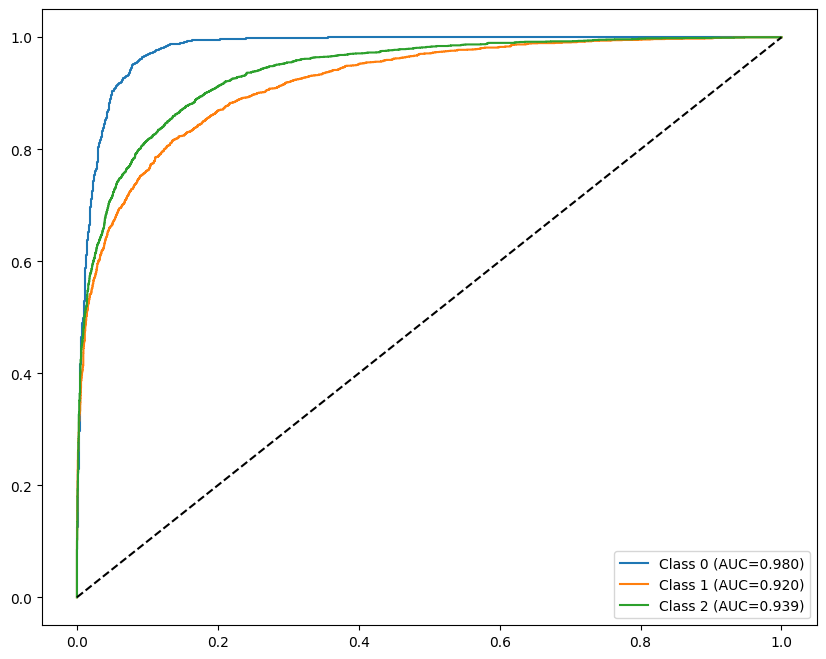

2026-03-21 19:05:34 | INFO | Indexed 7500 artifacts from val partition.


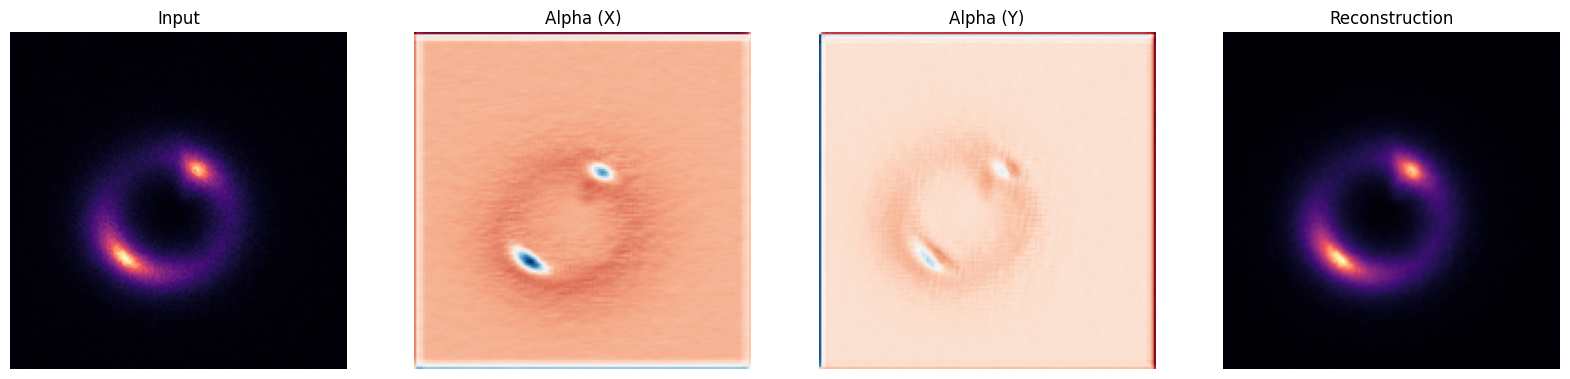

2026-03-21 19:05:35 | INFO | DeepLense pipeline execution complete.


In [8]:
if __name__ == "__main__":
    logger.info("Initiating DeepLense Task VII Evaluation Protocol...")
    config.artifact_dir.mkdir(parents=True, exist_ok=True)
    
    execute_pipeline(config, device)
    evaluate_pinn(config, device)
    visualize_reconstruction(config, device)
    
    logger.info("DeepLense pipeline execution complete.")